**Rehabilitation engineering Head tilt AI model.**

This project will use the AI vision model ResNet that is designed for classification/regression, which fits the target of classifying facial expressions, and creating a pain scale interface. 

The justification of using ResNet vision model: 

- 10-100 times faster than regular image models 
- needs less data than other vision models 
- directly outputs prediciton 
-much easier to debug 

The pipeline of this project will consist of: 

1. Input Image 

2. Convolutional Neural Network (CNN) (Resnet18)

3. Output Pain Score 

***The AI pain model pipeline:***

A more detailed summary of the coding pipeline of the AI model is explained below: 

1. Phase 1: image and pain intensity data processing (image_data_processing.py)
2. Phase 2: Creation of training and validation data (image_data_processing.py)
3. Phase 3: Data augmentation and dataloader setup (image_data_processing.py)
4. Phase 4: Creating the Resnet model (ResNet_model.py)
5. Phase 5: Training loop, validation loop, MAE / RMSE tracking and optimization (Training_ResNet.py)
6. Phase 6: Rebuilding the Resnet model with optimized wheights/parameters (Resnet_Rebuild.py)
7. Phase 7: Pain intensity prediction and performance testing (pain_prediction.py)


From the performance of the model, the training and validation losses are barely decreasing. 
This is due to training data being too small, only having input of 68 images, from 68 subjects. Increasing the training data should decrease the training and validation loss further, and predictions should become more accurate. 


New dataset estimate:

~68 people × 4 pain types × 20 images = ~5,440 images
Split by person: ~4,300+ in train, ~1,100+ in validation ✓
This should dramatically improve your model's ability to learn pain expressions since you now have:

Much more data per person
Different angles/expressions from the same video sequence
Still person-separated train/val (no leakage) ✓

In [25]:
import importlib
from pipeline import image_data_processing as imp
from pipeline import ResNet_model as resnet
from pipeline import Training_ResNet as train_resnet
from pipeline import pain_prediction as pain_pred

# Reload all modules to get latest changes
importlib.reload(imp)
importlib.reload(resnet)
importlib.reload(train_resnet)
importlib.reload(pain_pred)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

<module 'pipeline.pain_prediction' from 'c:\\Users\\Alexander  Hassfjell\\Documents\\Usyd\\Rehab engineering\\Rehab head tilt project code\\pipeline\\pain_prediction.py'>

In [28]:
#Phase 1: Sanity check that data is interpeted correctly

import pandas as pd


image_df= imp.process_images_head_pose(database_path="HeadPoseImageDatabase")


#train_df, val_df = imp.train_val_data_split(image_df, test_size=0.2, random_state=42)


# image df is split into train and val inside the function, 
#transformed with the class PainDataset, and then returned as dataloaders

print(image_df) #now much more data, 3313 images divided of 68 different people




Total images loaded: 5580
LEFT tilt (0): 2400
RIGHT tilt (1): 3180
                                             image_path tilt_direction
0     HeadPoseImageDatabase\Person01\person01100-90+...              0
1     HeadPoseImageDatabase\Person01\person01100-90+...              0
2     HeadPoseImageDatabase\Person01\person01101-60-...              0
3     HeadPoseImageDatabase\Person01\person01101-60-...              0
4     HeadPoseImageDatabase\Person01\person01102-60-...              0
...                                                 ...            ...
5575  HeadPoseImageDatabase\Person15\person15290+60+...              1
5576  HeadPoseImageDatabase\Person15\person15291+60+...              1
5577  HeadPoseImageDatabase\Person15\person15291+60+...              1
5578  HeadPoseImageDatabase\Person15\person15292+90+...              1
5579  HeadPoseImageDatabase\Person15\person15292+90+...              1

[5580 rows x 2 columns]


In [40]:
#IMPORTANT: Reload the module to get the corrected angle extraction
import importlib
importlib.reload(imp)

#Re-process images with corrected angle extraction
image_df = imp.process_images_head_pose(database_path="HeadPoseImageDatabase")

print("\nLabel distribution after corrected extraction:")
print(image_df['tilt_direction'].value_counts().sort_index())

Total images loaded: 5580
LEFT tilt (0): 2520
RIGHT tilt (1): 3060

Label distribution after corrected extraction:
tilt_direction
0    2520
1    3060
Name: count, dtype: int64


In [41]:
#Debug: Check actual angles extracted from database
import re

# Extract angles from all loaded filenames
sample_angles = []

for image_path in image_df['image_path'][:30]:  # Check first 30
    filename = image_path.split('\\')[-1]  # Get filename
    match = re.search(r'person\d+\d+([+-]\d+)([+-]\d+)', filename)
    if match:
        vertical = int(match.group(1))     # First group: vertical (pitch)
        horizontal = int(match.group(2))   # Second group: horizontal (yaw) - determines LEFT/RIGHT
        sample_angles.append((filename, vertical, horizontal))

print("Sample filenames with corrected angle extraction:")
print("-" * 70)
for fname, vert, horiz in sample_angles[:15]:
    label = 0 if horiz < 0 else 1
    print(f"{fname:30s} | Vert: {vert:3d}° | Horiz: {horiz:3d}° | Label: {label} ({'LEFT' if label==0 else 'RIGHT'})")

print(f"\nOverall label distribution in loaded data:")
print(f"  LEFT (label 0):   {(image_df['tilt_direction'] == 0).sum()} images")
print(f"  RIGHT (label 1):  {(image_df['tilt_direction'] == 1).sum()} images")

Sample filenames with corrected angle extraction:
----------------------------------------------------------------------
person01100-90+0.jpg           | Vert: -90° | Horiz:   0° | Label: 1 (RIGHT)
person01100-90+0.txt           | Vert: -90° | Horiz:   0° | Label: 1 (RIGHT)
person01101-60-90.jpg          | Vert: -60° | Horiz: -90° | Label: 0 (LEFT)
person01101-60-90.txt          | Vert: -60° | Horiz: -90° | Label: 0 (LEFT)
person01102-60-75.jpg          | Vert: -60° | Horiz: -75° | Label: 0 (LEFT)
person01102-60-75.txt          | Vert: -60° | Horiz: -75° | Label: 0 (LEFT)
person01103-60-60.jpg          | Vert: -60° | Horiz: -60° | Label: 0 (LEFT)
person01103-60-60.txt          | Vert: -60° | Horiz: -60° | Label: 0 (LEFT)
person01104-60-45.jpg          | Vert: -60° | Horiz: -45° | Label: 0 (LEFT)
person01104-60-45.txt          | Vert: -60° | Horiz: -45° | Label: 0 (LEFT)
person01105-60-30.jpg          | Vert: -60° | Horiz: -30° | Label: 0 (LEFT)
person01105-60-30.txt          | Vert: -6

In [42]:
#Debug: Check if angles are being extracted correctly
import re

# Test with your specific example
test_filenames = [
    "person08108-60+15.txt",  # Your example: +15 = RIGHT
    "person01100-90+0.txt",   # +0 = RIGHT (center, but positive)
    "person01101-60-90.txt",  # -90 = LEFT (strong left)
    "person01147+0+15.txt"    # +15 = RIGHT
]

print("Testing angle extraction with YOUR example:")
print("="*70)
for fname in test_filenames:
    match = re.search(r'person\d+\d+([+-]\d+)([+-]\d+)', fname)
    if match:
        pitch = int(match.group(1))        # First signed number (vertical)
        yaw = int(match.group(2))          # Second signed number (horizontal) - DETERMINES LEFT/RIGHT
        label = 0 if yaw < 0 else 1
        print(f"Filename: {fname}")
        print(f"  Pitch (vert): {pitch:3d}° | Yaw (horiz): {yaw:3d}° | Label: {label} ({'LEFT' if label==0 else 'RIGHT'})")
    else:
        print(f"{fname} - NO MATCH!")
print("="*70)

Testing angle extraction with YOUR example:
Filename: person08108-60+15.txt
  Pitch (vert): -60° | Yaw (horiz):  15° | Label: 1 (RIGHT)
Filename: person01100-90+0.txt
  Pitch (vert): -90° | Yaw (horiz):   0° | Label: 1 (RIGHT)
Filename: person01101-60-90.txt
  Pitch (vert): -60° | Yaw (horiz): -90° | Label: 0 (LEFT)
Filename: person01147+0+15.txt
  Pitch (vert):   0° | Yaw (horiz):  15° | Label: 1 (RIGHT)


Phase 2 and 3 include the last steps of the image_data_processing.py where the image_df dataframe are transfomred to Resnet format and put into dataloaders ready for use into the resnet model. 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Train: 12 persons, 4464 images
Val: 3 persons, 1116 images

Dataloaders created:
Train batches: 140 (batch_size=32)
Val batches: 35 (batch_size=32)
Train dataset:  <pipeline.image_data_processing.HeadTiltDataset object at 0x000001A1D8200AD0>
train loader type:  <class 'torch.utils.data.dataloader.DataLoader'>
<class 'torch.Tensor'>
torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor([0, 0, 1, 1, 0])


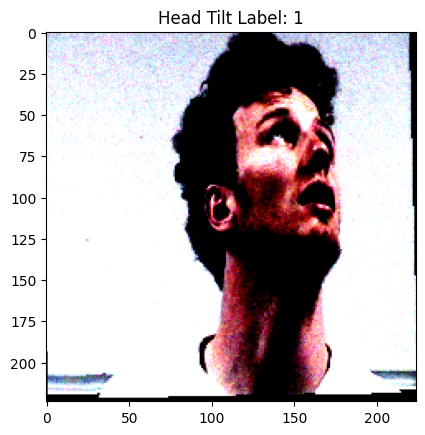

In [47]:
#Phase 2 and 3: Sanity check the dataloaders, checking training data and validation data has been configured correctly 
# and that the data is being loaded as expected. 
# This includes checking the shapes of the images and labels, 
# and visualizing some samples from the dataloader to ensure that the images
#  are being processed correctly and that the pain intensity labels are accurate.
train_loader, val_loader = imp.create_dataloaders(image_df) 

print('Train dataset: ', train_loader.dataset)
print('train loader type: ',type(train_loader))  # should be <class 'torch.utils.data.dataloader.DataLoader'>
images, head_label = next(iter(train_loader)) #every time the code runs it will give a different batch of images and pain intensities from the train loader, which is useful for checking the data loading process

print(type(images))  # should be <class 'torch.Tensor'>

print(images.shape)  # should be [32, 3, 224, 224]
print(head_label.shape)  # should be [32]
print(head_label[:5])

import matplotlib.pyplot as plt

img = images[20].permute(1, 2, 0).numpy() #what does permute do here? answer: it changes the order of the dimensions from (C, H, W) to (H, W, C) which is needed for displaying the image with matplotlib
plt.imshow(img)
plt.title(f"Head Tilt Label: {head_label[20].item()}")
plt.show()


Phase 4: The next code block checks that the Resnet model is set up correctly, and that the optimization and loss criterion are working optimally. 

In [48]:
#phase 4: Sanity check that the ResNet model is setup correctly 

images, labels = next(iter(train_loader))

images = images.to(resnet.device)
labels = labels.to(resnet.device)

outputs = resnet.model(images)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Output batch shape:", outputs.shape)

#Correct output: 
#images: [32, 3, 224, 224]
#labels: [32]
#outputs: [32, 1]

outputs = outputs.squeeze(1) #removing the extra dimension from the model's output, 
#labels are of shape [32] and outputs are of shape [32, 1],
#  so we need to squeeze the outputs to match the shape of the labels for the loss calculation
loss = resnet.criterion(outputs, labels) 
#taking the loss between the model's predictions 
# and the true pain intensity labels, 
# which will be used to update the model's weights during training
print("Loss:", type(loss), loss.item())  # should be a single scalar value representing the loss for the batch, 
#The batch is the group of 32 images and their corresponding pain intensity labels that were loaded from the train_loader,
# and the loss for the batch is the 
# average loss across all 32 samples in the batch, 
# which gives us an indication of how well the model is performing on that batch of data.


Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Output batch shape: torch.Size([32, 2])
Loss: <class 'torch.Tensor'> 0.628397524356842


In [49]:
#Preparing for training phase 5: 






 # Scale the pain labels to a range of 1-10

train_loader, val_loader = imp.create_dataloaders(image_df)


Train: 12 persons, 4464 images
Val: 3 persons, 1116 images

Dataloaders created:
Train batches: 140 (batch_size=32)
Val batches: 35 (batch_size=32)


In [50]:
# Debug: Check train and validation loader pain intensity distributions

# Extract all pain intensities from train and val loaders
train_intensities = []
val_intensities = []

for _, labels in train_loader:
    train_intensities.extend(labels.numpy())

for _, labels in val_loader:
    val_intensities.extend(labels.numpy())

import numpy as np

print("=" * 60)
print("TRAIN vs VALIDATION PAIN INTENSITY COMPARISON")
print("=" * 60)

print("\nTRAIN SET:")
print(f"  Count: {len(train_intensities)}")
print(f"  Min: {np.min(train_intensities):.2f}")
print(f"  Max: {np.max(train_intensities):.2f}")
print(f"  Mean: {np.mean(train_intensities):.2f}")
print(f"  Std: {np.std(train_intensities):.2f}")

print("\nVALIDATION SET:")
print(f"  Count: {len(val_intensities)}")
print(f"  Min: {np.min(val_intensities):.2f}")
print(f"  Max: {np.max(val_intensities):.2f}")
print(f"  Mean: {np.mean(val_intensities):.2f}")
print(f"  Std: {np.std(val_intensities):.2f}")

print("\nDIFFERENCES:")
print(f"  Mean difference: {abs(np.mean(train_intensities) - np.mean(val_intensities)):.2f}")
print(f"  Range difference: Train={np.max(train_intensities) - np.min(train_intensities):.2f}, Val={np.max(val_intensities) - np.min(val_intensities):.2f}")
print("=" * 60)

TRAIN vs VALIDATION PAIN INTENSITY COMPARISON

TRAIN SET:
  Count: 4464
  Min: 0.00
  Max: 1.00
  Mean: 0.55
  Std: 0.50

VALIDATION SET:
  Count: 1116
  Min: 0.00
  Max: 1.00
  Mean: 0.55
  Std: 0.50

DIFFERENCES:
  Mean difference: 0.00
  Range difference: Train=1.00, Val=1.00


Phase 5: Next code block executes the training of the Resnet model that are found in Training_resnet.py on the training and validation dataloaders prepared from phase 3. The most optimized parameters that produce the lowest validation loss are in the end saved to checkpoint.pth that are later retrieved when we rebuild the resnet model and apply it on pain intensity predictions.

In [ ]:
#Phase 5:  Training the model, and updating the wheights/parameters based on the loss, 
# and checking that the training loop is working correctly,
# ensuring that the model is able to learn from the data 
# and that the loss is decreasing over time.

#history = train_resnet.train_model( #DO NOT RUN THIS CELL UNLESS YOU WANT TO TRAIN THE MODEL, IT WILL TAKE A LONG TIME TO RUN
    model= resnet.model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=resnet.criterion,
    optimizer=resnet.optimizer,
    device=resnet.device,
    scheduler=resnet.scheduler,
    num_epochs=20)

Epoch [1/20]
  Train Loss: 0.3788 | Train Acc: 0.8172 | Train F1: 0.8375
  Val   Loss: 0.5571 | Val   Acc: 0.7079 | Val   F1: 0.7155
✓ Saved best model checkpoint.
------------------------------------------------------------
Epoch [2/20]
  Train Loss: 0.1358 | Train Acc: 0.9456 | Train F1: 0.9506
  Val   Loss: 0.4172 | Val   Acc: 0.8208 | Val   F1: 0.8282
✓ Saved best model checkpoint.
------------------------------------------------------------
Epoch [3/20]
  Train Loss: 0.0961 | Train Acc: 0.9633 | Train F1: 0.9665
  Val   Loss: 0.4995 | Val   Acc: 0.8011 | Val   F1: 0.7802
------------------------------------------------------------
Epoch [4/20]
  Train Loss: 0.0743 | Train Acc: 0.9722 | Train F1: 0.9747
  Val   Loss: 0.4921 | Val   Acc: 0.8172 | Val   F1: 0.8083
------------------------------------------------------------
Epoch [5/20]
  Train Loss: 0.0651 | Train Acc: 0.9745 | Train F1: 0.9767
  Val   Loss: 0.5285 | Val   Acc: 0.7993 | Val   F1: 0.7829
-----------------------------

In [18]:
print(history)

NameError: name 'history' is not defined

Phase 6: Are explained in the Resnet_rebuild.py and consists of rebuliding the resnet model training it on the optimized parameters that was found from training the model in phase 5. 

Phase 7: Is the final phase explained in pain_prediction.py, where the rebuilt resnet model from phase 6 are trialled on inputs of random images, and the model is set to predict a single scalar pain intensity as output. 

Phase 8 (future steps): Would be to create a more pleasing UI pain scale output, with a visual interface that could be used as the final product for the AI paijn prediction project. 

In [3]:
image_path = r"Connor.jpeg"

try:
    score = pain_pred.predict_tilt(image_path, pain_pred.trained_model, pain_pred.transform, pain_pred.device)
    pain_pred.show_prediction(image_path, score, display=True)
    print(f"✓ Predicted head tilt: {score}")
except Exception as e:
    print(f"✗ Error: {e}")

  [1] Loading image from: Connor.jpeg
  [2] Image loaded: shape (2290, 1911, 3)
  [3] Color converted to RGB
  [4] Applying transforms...
  [5] Transform applied, shape: torch.Size([3, 224, 224])
  [6] Adding batch dimension...
  [7] Batch dimension added, shape: torch.Size([1, 3, 224, 224])
  [8] Running model inference...
  [9] Model output shape: torch.Size([1, 2])
  [10] Model output values: tensor([[-2.3757,  2.1783]])
  [11] Predicted class index: 1
  [12] Final prediction: RIGHT


KeyboardInterrupt: 

In [4]:
image_path = r"Kasper.jpeg"

try:
    score = pain_pred.predict_tilt(image_path, pain_pred.trained_model, pain_pred.transform, pain_pred.device)
    pain_pred.show_prediction(image_path, score, display=True)
    print(f"✓ Predicted head tilt: {score}")
except Exception as e:
    print(f"✗ Error: {e}")

  [1] Loading image from: Kasper.jpeg
  [2] Image loaded: shape (2326, 2007, 3)
  [3] Color converted to RGB
  [4] Applying transforms...
  [5] Transform applied, shape: torch.Size([3, 224, 224])
  [6] Adding batch dimension...
  [7] Batch dimension added, shape: torch.Size([1, 3, 224, 224])
  [8] Running model inference...
  [9] Model output shape: torch.Size([1, 2])
  [10] Model output values: tensor([[ 0.4709, -1.0898]])
  [11] Predicted class index: 0
  [12] Final prediction: LEFT


KeyboardInterrupt: 

In [1]:
import importlib
from pipeline import image_data_processing as imp
from pipeline import ResNet_model as resnet
from pipeline import Training_ResNet as train_resnet
from pipeline import pain_prediction as pain_pred

# Reload all modules to get latest changes
importlib.reload(imp)
importlib.reload(resnet)
importlib.reload(train_resnet)
importlib.reload(pain_pred)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

<module 'pipeline.pain_prediction' from 'c:\\Users\\Alexander  Hassfjell\\Documents\\Usyd\\Rehab engineering\\Rehab head tilt project code\\pipeline\\pain_prediction.py'>

In [ ]:
# Reload webcam module with updated GUI
from Interface import Webcam_access as webcam
importlib.reload(webcam)

# Launch the interactive GUI with button control
webcam.capture_with_button_gui()

In [5]:
# Delete captured images (run this cell anytime to clear the captured_images folder)
from Interface import Webcam_access as webcam
webcam.delete_captured_images(folder="captured_images")


DELETING CAPTURED IMAGES
  ✓ Deleted: img_20260424_110609.jpg
  ✓ Deleted: img_20260424_110617.jpg
  ✓ Deleted: img_20260424_110624.jpg
  ✓ Deleted: img_20260424_110625.jpg

✓ Successfully deleted 4 image(s)

